In [5]:
import pandas as pd
import numpy as np
import pickle
import umap
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

def load_reddit_pipeline_data(csv_path="../../data/reddit_features_22_3_meh.csv", 
                              pkl_prefix="processed_v1", 
                              output_dir="../../data",
                              target_col="score"):
    """
    Loads the original csv to retrieve the target variable, 
    recreates the exact random splits used by the pipeline, 
    and loads the pickled features (which contain embeddings + extra features).
    Returns DataFrames with proper column names.
    """
    print("Loading metadata from CSV...")
    # 1. Load the original metadata to get the target variable (e.g. 'score')
    # Note: Use the CSV that contains the engineered forum_* features.
    df = pd.read_csv(csv_path)
    
    # 2. Recreate the exact same splits used in save_final_features
    np.random.seed(42)
    df['split'] = np.random.choice(['train', 'val', 'test'], size=len(df), p=[0.7, 0.15, 0.15])
    
    # Preprocess target (as used in regresson model)
    df['log_score'] = np.log1p(df[target_col].clip(lower=0))
    
    # Determine feature names to reconstruct DataFrames
    extra_features = ['comment_existence', 'hour', 'ttr', 'hapax', 'stopword_ratio',
                      'burstiness', 'punctuation_density', 'hedging_score', 'self_reference_rate']
    forum_cols = [c for c in df.columns if c.startswith('forum_')]
    extra_features.extend(forum_cols)
    present_features = [f for f in extra_features if f in df.columns]
    
    # 3. Load the pickled features
    splits = ['train', 'val', 'test']
    X_dict = {}
    y_dict = {}
    
    for split_name in splits:
        # Load features 
        split_filename = f"{output_dir}/{pkl_prefix}_features_{split_name}.pkl"
        with open(split_filename, 'rb') as f:
            X_split = pickle.load(f)
            
        # Construct column names: [base_features..., emb_0, emb_1, ...]
        num_embeddings = X_split.shape[1] - len(present_features)
        emb_cols = [f'emb_{i}' for i in range(num_embeddings)]
        all_cols = present_features + emb_cols
        
        # Convert to DataFrame for easier plotting later
        X_df = pd.DataFrame(X_split, columns=all_cols)
        
        # Get target variable for this split
        y_split = df[df['split'] == split_name]['log_score'].values
        
        X_dict[split_name] = X_df
        y_dict[split_name] = y_split
        
        print(f"[{split_name.upper()}] Loaded X shape: {X_split.shape}, y shape: {y_split.shape}")
        
    return X_dict, y_dict, df


In [6]:
# 1. Load the pre-split, pre-engineered data!
# This replaces all the manual splitting and concatenation.
X_data, y_data, df_metadata = load_reddit_pipeline_data()
X_train_raw = X_data['train']
y_train = y_data['train']
X_val_raw = X_data['val']
y_val = y_data['val']
X_test_raw = X_data['test']
y_test = y_data['test']

# Isolate base features and embeddings for UMAP later
base_cols = [c for c in X_train_raw.columns if not c.startswith('emb_')]
emb_cols = [c for c in X_train_raw.columns if c.startswith('emb_')]

X_base_train = X_train_raw[base_cols]
emb_train = X_train_raw[emb_cols]
X_base_val = X_val_raw[base_cols]
emb_val = X_val_raw[emb_cols]
X_base_test = X_test_raw[base_cols]
emb_test = X_test_raw[emb_cols]

print(f"Base Training Shape: {X_base_train.shape}")
print(f"Embeddings Training Shape: {emb_train.shape}")

# Train the basic model
print("Training Reddit Random Forest with Raw Embeddings...")
model_rf_raw = RandomForestRegressor(
    n_estimators=500, max_depth=6, max_features=0.8, max_samples=0.8, n_jobs=-1, random_state=42
)
model_rf_raw.fit(X_train_raw, y_train)

r2_val_raw = r2_score(y_val, model_rf_raw.predict(X_val_raw))
r2_test_raw = r2_score(y_test, model_rf_raw.predict(X_test_raw))
print(f"Reddit Raw R2 Validation: {r2_val_raw:.4f}")
print(f"Reddit Raw R2 Test: {r2_test_raw:.4f}")


Loading metadata from CSV...
[TRAIN] Loaded X shape: (24514, 773), y shape: (24514,)
[VAL] Loaded X shape: (5169, 773), y shape: (5169,)
[TEST] Loaded X shape: (5184, 773), y shape: (5184,)
Base Training Shape: (24514, 12)
Embeddings Training Shape: (24514, 761)
Training Reddit Random Forest with Raw Embeddings...
Reddit Raw R2 Validation: 0.4396
Reddit Raw R2 Test: 0.4290


In [7]:
# ==========================================
# MODEL 2: UMAP (Base + UMAP Reduced Embeddings)
# ==========================================
print("Training Reddit Model 2: UMAP (Base + UMAP Reduced Embeddings)...")
n_components = 50
print(f"Fitting UMAP (n_components={n_components}) strictly on training embeddings...")
reducer = umap.UMAP(n_components=n_components, random_state=42)

emb_train_umap = reducer.fit_transform(emb_train)
emb_val_umap = reducer.transform(emb_val)
emb_test_umap = reducer.transform(emb_test)

umap_cols = [f'umap_emb_{i}' for i in range(n_components)]
df_emb_train_umap = pd.DataFrame(emb_train_umap, index=X_base_train.index, columns=umap_cols)
df_emb_val_umap = pd.DataFrame(emb_val_umap, index=X_base_val.index, columns=umap_cols)
df_emb_test_umap = pd.DataFrame(emb_test_umap, index=X_base_test.index, columns=umap_cols)

X_train_umap = pd.concat([X_base_train, df_emb_train_umap], axis=1)
X_val_umap = pd.concat([X_base_val, df_emb_val_umap], axis=1)
X_test_umap = pd.concat([X_base_test, df_emb_test_umap], axis=1)

model_rf_umap = RandomForestRegressor(
    n_estimators=500, max_depth=6, max_features=0.8, max_samples=0.8, n_jobs=-1, random_state=42
)
model_rf_umap.fit(X_train_umap, y_train)

r2_val_umap = r2_score(y_val, model_rf_umap.predict(X_val_umap))
r2_test_umap = r2_score(y_test, model_rf_umap.predict(X_test_umap))
print(f"Reddit UMAP R2 Validation: {r2_val_umap:.4f}")
print(f"Reddit UMAP R2 Test: {r2_test_umap:.4f}")

Training Reddit Model 2: UMAP (Base + UMAP Reduced Embeddings)...
Fitting UMAP (n_components=50) strictly on training embeddings...


c:\Users\Rald999\Anaconda3\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Rald999\Anaconda3\lib\site-packages\scipy\sparse\_index.py:146: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


Reddit UMAP R2 Validation: 0.4413
Reddit UMAP R2 Test: 0.4269


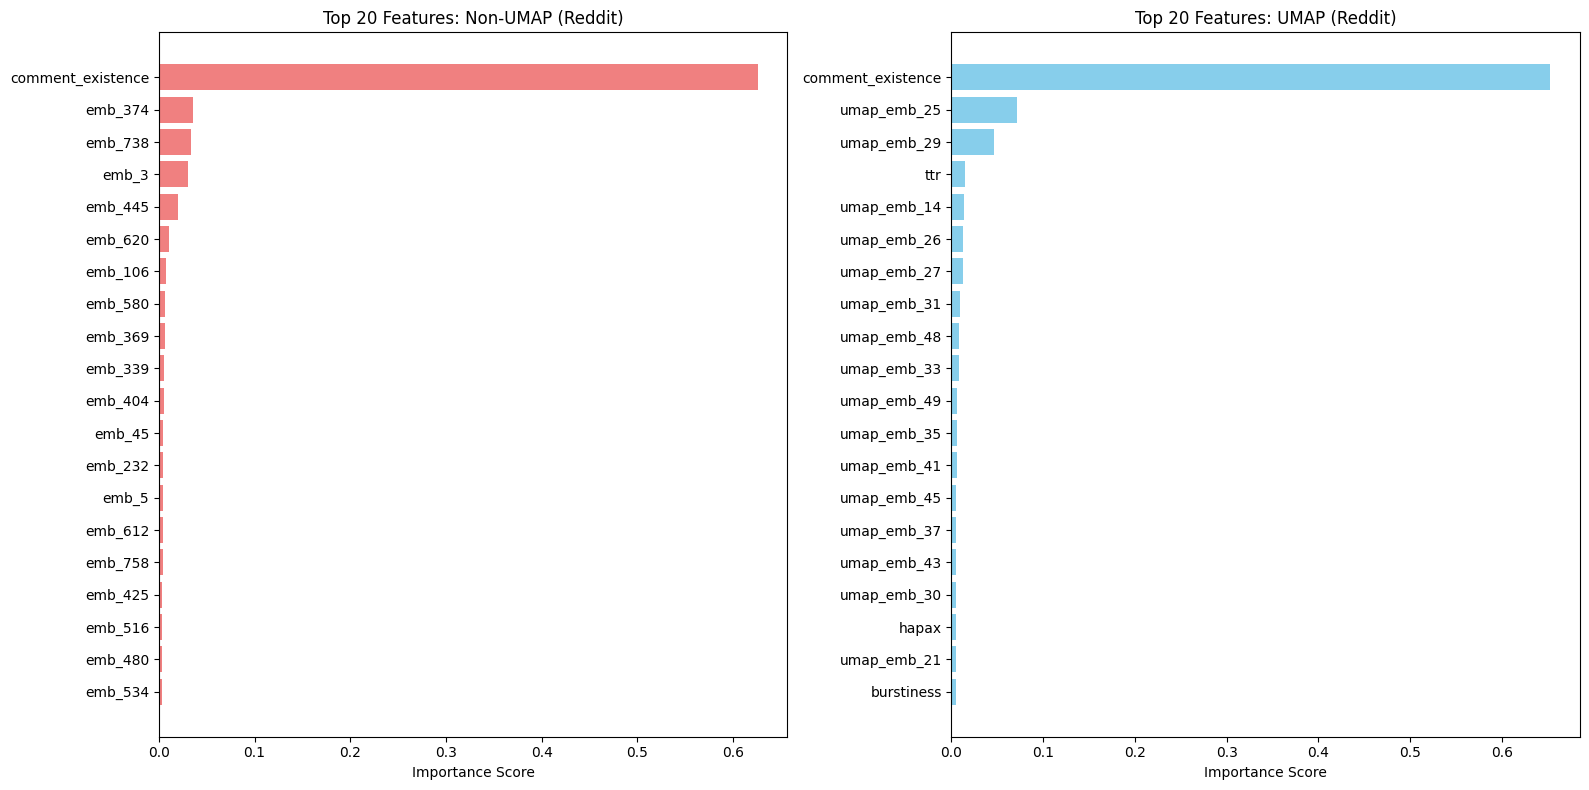

In [8]:
# ==========================================
# VISUALIZE FEATURE IMPORTANCES
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
top_n = 20

# Plot 1: Non-UMAP
importances_raw = model_rf_raw.feature_importances_
df_imp_raw = pd.DataFrame({'Feature': X_train_raw.columns, 'Importance': importances_raw})
df_imp_raw = df_imp_raw.sort_values(by='Importance', ascending=False).head(top_n)
axes[0].barh(df_imp_raw['Feature'][::-1], df_imp_raw['Importance'][::-1], color='lightcoral')
axes[0].set_title(f'Top {top_n} Features: Non-UMAP (Reddit)')
axes[0].set_xlabel('Importance Score')

# Plot 2: UMAP
importances_umap = model_rf_umap.feature_importances_
df_imp_umap = pd.DataFrame({'Feature': X_train_umap.columns, 'Importance': importances_umap})
df_imp_umap = df_imp_umap.sort_values(by='Importance', ascending=False).head(top_n)
axes[1].barh(df_imp_umap['Feature'][::-1], df_imp_umap['Importance'][::-1], color='skyblue')
axes[1].set_title(f'Top {top_n} Features: UMAP (Reddit)')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [9]:
# 9. Generate Learning Curve
print("Generating Reddit Learning Curve...")
train_sizes = np.linspace(0.1, 1.0, 5)
train_sizes_abs, train_scores, val_scores = learning_curve(
    model_rf_raw, X_train_raw, y_train, 
    train_sizes=train_sizes, 
    cv=3, 
    scoring='r2', 
    n_jobs=-1
)

train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes_abs, train_scores_mean, 'o-', color='blue', label='Training Score')
plt.plot(train_sizes_abs, val_scores_mean, 'o-', color='orange', label='Validation Score')
plt.title('Random Forest Learning Curve (Reddit)')
plt.xlabel('Number of Training Examples')
plt.ylabel('R2 Score')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

Generating Reddit Learning Curve...


NameError: name 'learning_curve' is not defined